TRABAJO FINAL OBLIGATORIO


# EL OBJETIVO DEL TRABAJO ES ANALIZAR LOS PARAMETROS DE LOS JUGADORES PARA PREVER SUS POSIBLES FUNCIONALIDADES O PUESTOS A CUBRIR DENTRO DE LA CANCHA

In [3]:
# importacion de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATASET

In [4]:
!ls /content/drive/MyDrive/datos_final

ls: cannot access '/content/drive/MyDrive/datos_final': No such file or directory


In [5]:
from google.colab import drive
drive.mount('/content/drive')

# Now, load your dataset using pandas from the correct path after mounting
df = pd.read_csv('/content/drive/MyDrive/datos final/2022-2023FootballPlayerStats.csv', encoding='latin1', sep=';')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
print(df.columns.tolist())

['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Goals', 'Shots', 'SoT', 'SoT%', 'G/Sh', 'G/SoT', 'ShoDist', 'ShoFK', 'ShoPK', 'PKatt', 'PasTotCmp', 'PasTotAtt', 'PasTotCmp%', 'PasTotDist', 'PasTotPrgDist', 'PasShoCmp', 'PasShoAtt', 'PasShoCmp%', 'PasMedCmp', 'PasMedAtt', 'PasMedCmp%', 'PasLonCmp', 'PasLonAtt', 'PasLonCmp%', 'Assists', 'PasAss', 'Pas3rd', 'PPA', 'CrsPA', 'PasProg', 'PasAtt', 'PasLive', 'PasDead', 'PasFK', 'TB', 'Sw', 'PasCrs', 'TI', 'CK', 'CkIn', 'CkOut', 'CkStr', 'PasCmp', 'PasOff', 'PasBlocks', 'SCA', 'ScaPassLive', 'ScaPassDead', 'ScaDrib', 'ScaSh', 'ScaFld', 'ScaDef', 'GCA', 'GcaPassLive', 'GcaPassDead', 'GcaDrib', 'GcaSh', 'GcaFld', 'GcaDef', 'Tkl', 'TklWon', 'TklDef3rd', 'TklMid3rd', 'TklAtt3rd', 'TklDri', 'TklDriAtt', 'TklDri%', 'TklDriPast', 'Blocks', 'BlkSh', 'BlkPass', 'Int', 'Tkl+Int', 'Clr', 'Err', 'Touches', 'TouDefPen', 'TouDef3rd', 'TouMid3rd', 'TouAtt3rd', 'TouAttPen', 'TouLive', 'ToAtt', 'ToSuc', 'ToSuc%'

In [7]:
print(df.nunique())

Rk         2689
Player     2530
Nation      104
Pos          10
Squad        98
           ... 
OG           20
Recov       707
AerWon      410
AerLost     402
AerWon%     390
Length: 124, dtype: int64


In [8]:
display(df.head())


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
0,1,Brenden Aaronson,USA,MFFW,Leeds United,Premier League,22,2000,20,19,...,0.17,2.54,0.51,0.0,0.0,0.00,4.86,0.34,1.19,22.2
1,2,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,35,1987,22,22,...,0.05,0.18,1.59,0.0,0.0,0.00,6.64,2.18,1.23,64.0
2,3,Himad Abdelli,FRA,MFFW,Angers,Ligue 1,23,1999,14,8,...,0.00,1.05,1.40,0.0,0.0,0.00,8.14,0.93,1.05,47.1
3,4,Salis Abdul Samed,GHA,MF,Lens,Ligue 1,22,2000,20,20,...,0.00,0.35,0.80,0.0,0.0,0.05,6.60,0.50,0.50,50.0
4,5,Laurent Abergel,FRA,MF,Lorient,Ligue 1,30,1993,15,15,...,0.00,0.23,2.02,0.0,0.0,0.00,6.51,0.31,0.39,44.4


**2. Exploración de Datos: Diccionario de Variables**
El dataset contiene 124 variables que describen el rendimiento de más de 2500 jugadores. Para facilitar el análisis, las hemos agrupado en 6 dimensiones clave:

Para facilitar la comprensión del dataset **2022-2023 Football Player Stats**, hemos categorizado las 124 columnas en dimensiones clave que describen el perfil de cada futbolista:

### **A. Identificación y Contexto**
* **Player**: Nombre del futbolista.
* **Nation**: Nacionalidad (Código ISO).
* **Pos**: Posición principal (DF=Defensa, MF=Mediocampista, FW=Delantero, GK=Arquero).
* **Squad**: Nombre del equipo.
* **Comp**: Liga a la que pertenece (Top 5 ligas europeas).
* **Age / Born**: Edad actual y año de nacimiento del jugador.

### **B. Participación y Disponibilidad**
* **MP / Starts**: Partidos jugados y partidos como titular.
* **Min / 90s**: Minutos totales jugados y su equivalente en fracciones de 90 minutos (unidad estándar de análisis).

### **C. Rendimiento Ofensivo (Finalización)**
* **Goals**: Goles anotados (sin contar definiciones por penales).
* **Shots / SoT**: Remates totales y remates al arco.
* **G/Sh**: Eficiencia de gol por cada remate realizado.
* **ShoDist**: Distancia promedio (en yardas) desde donde el jugador remata.
* **ShoFK / ShoPK**: Remates de tiro libre y penales convertidos.

### **D. Distribución y Creación de Juego**
* **PasTotCmp / PasTotAtt**: Pases completados e intentados totales.
* **PasTotCmp%**: Porcentaje de precisión en el pase.
* **Assists**: Asistencias que terminaron en gol.
* **PasAss (Key Passes)**: Pases que terminaron directamente en un remate de un compañero.
* **PPA**: Pases completados dentro del área de 18 yardas.
* **PasProg**: Pases progresivos que mueven el balón hacia el arco rival al menos 10 yardas.
* **SCA (Shot-Creating Actions)**: Acciones ofensivas (pases, regates, faltas recibidas) que derivan en un tiro.

### **E. Defensa y Recuperación**
* **Tkl / TklWon**: Tackles totales e intentados donde el equipo recuperó la posesión.
* **TklDef3rd / TklMid3rd / TklAtt3rd**: Tackles realizados en zona defensiva, central u ofensiva.
* **Int**: Intercepciones de pases rivales.
* **Blocks**: Cantidad de veces que bloqueó el balón (tiros o pases).
* **Clr**: Despejes de la zona de peligro.
* **AerWon / AerWon%**: Duelos aéreos ganados y su porcentaje de éxito.

### **F. Posesión y Progresión Individual**
* **Touches**: Cantidad de veces que el jugador tocó la pelota.
* **TouAttPen**: Toques de balón dentro del área rival.
* **ToSuc / ToSuc%**: Regates (Take-ons) completados con éxito y efectividad.
* **CarProg**: Conducciones de balón que progresan hacia el arco rival.
* **CarMis / CarDis**: Pérdidas de balón por mal control o por ser tackleado por un rival.

### **G. Disciplina**
* **CrdY / CrdR**: Tarjetas amarillas y rojas recibidas.
* **Fls / Fld**: Faltas cometidas y faltas recibidas.

## 3. Limpieza de Datos


Para asegurar que nuestro análisis y modelo de Machine Learning sean precisos, aplicamos las siguientes técnicas de limpieza:

1. **Filtrado por tiempo de juego**: Eliminamos a los jugadores con menos de **5 unidades de 90 minutos (450 minutos totales)**. Esto evita que jugadores con participaciones mínimas distorsionen los promedios (ej. un jugador que jugó 2 minutos y anotó un gol tendría una estadística de 45 goles por partido).
2. **Tratamiento de valores nulos**: Identificamos columnas con datos faltantes. En las métricas de rendimiento (goles, pases, tackles), los valores nulos se imputaron con **0**, asumiendo que la ausencia de registro equivale a que la acción no ocurrió.
3. **Simplificación de Posiciones**: Algunos jugadores tienen posiciones compuestas (ej. 'DF,MF'). Para facilitar la clasificación, nos quedamos únicamente con la **primera posición** registrada.
4. **Eliminación de redundancias**: Se eliminaron columnas como `Rk` y `Born`, ya que no aportan valor predictivo o ya están representadas por `Age`.

In [9]:

# 1. Eliminar columnas innecesarias
df_clean = df.drop(columns=['Rk', 'Born'])

# 2. Filtrar jugadores con pocos minutos (Minimo 5 partidos de 90 min)
# Esto limpia el ruido estadístico
df_clean = df_clean[df_clean['90s'] >= 5.0].reset_index(drop=True)

# 3. Limpiar la columna de Posiciones (Pos)
# Nos quedamos solo con la primera parte antes de la coma o el espacio
df_clean['Pos'] = df_clean['Pos'].str[:2]

# 4. Manejo de valores nulos
# Identificamos columnas numéricas para rellenar con 0
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(0)

# 5. Verificación final
print(f"Dataset original: {df.shape}")
print(f"Dataset limpio: {df_clean.shape}")
print("\nConteo de posiciones:")
print(df_clean['Pos'].value_counts())

# Mostrar los primeros registros limpios
df_clean.head()

Dataset original: (2689, 124)
Dataset limpio: (1637, 122)

Conteo de posiciones:
Pos
DF    648
MF    506
FW    363
GK    120
Name: count, dtype: int64


,Player,Nation,Pos,Squad,Comp,Age,MP,Starts,Min,90s,...,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
0,Brenden Aaronson,USA,MF,Leeds United,Premier League,22,20,19,1596,17.7,...,0.17,2.54,0.51,0.0,0.0,0.00,4.86,0.34,1.19,22.2
1,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,35,22,22,1980,22.0,...,0.05,0.18,1.59,0.0,0.0,0.00,6.64,2.18,1.23,64.0
2,Himad Abdelli,FRA,MF,Angers,Ligue 1,23,14,8,770,8.6,...,0.00,1.05,1.40,0.0,0.0,0.00,8.14,0.93,1.05,47.1
3,Salis Abdul Samed,GHA,MF,Lens,Ligue 1,22,20,20,1799,20.0,...,0.00,0.35,0.80,0.0,0.0,0.05,6.60,0.50,0.50,50.0
4,Laurent Abergel,FRA,MF,Lorient,Ligue 1,30,15,15,1165,12.9,...,0.00,0.23,2.02,0.0,0.0,0.00,6.51,0.31,0.39,44.4


## 4. Análisis Estadístico Descriptivo

En esta etapa, exploramos las tendencias centrales y la dispersión de los datos para entender el perfil de los jugadores en las ligas top de Europa:

1.  **Análisis de Variables Categóricas**: Observamos la distribución de jugadores por posición y liga para asegurar que la muestra sea equilibrada.
2.  **Análisis de Variables Numéricas**: Evaluamos la relación entre la creación de oportunidades (SCA) y la finalización (Goles), así como la distribución de la edad en la élite del fútbol.
3.  **Identificación de Outliers**: Buscamos jugadores que rompen la norma estadística (los "fuera de serie") en métricas de pases y goles.

/tmp/ipykernel_1464/1160213698.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Pos', palette='viridis', order=df_clean['Pos'].value_counts().index)


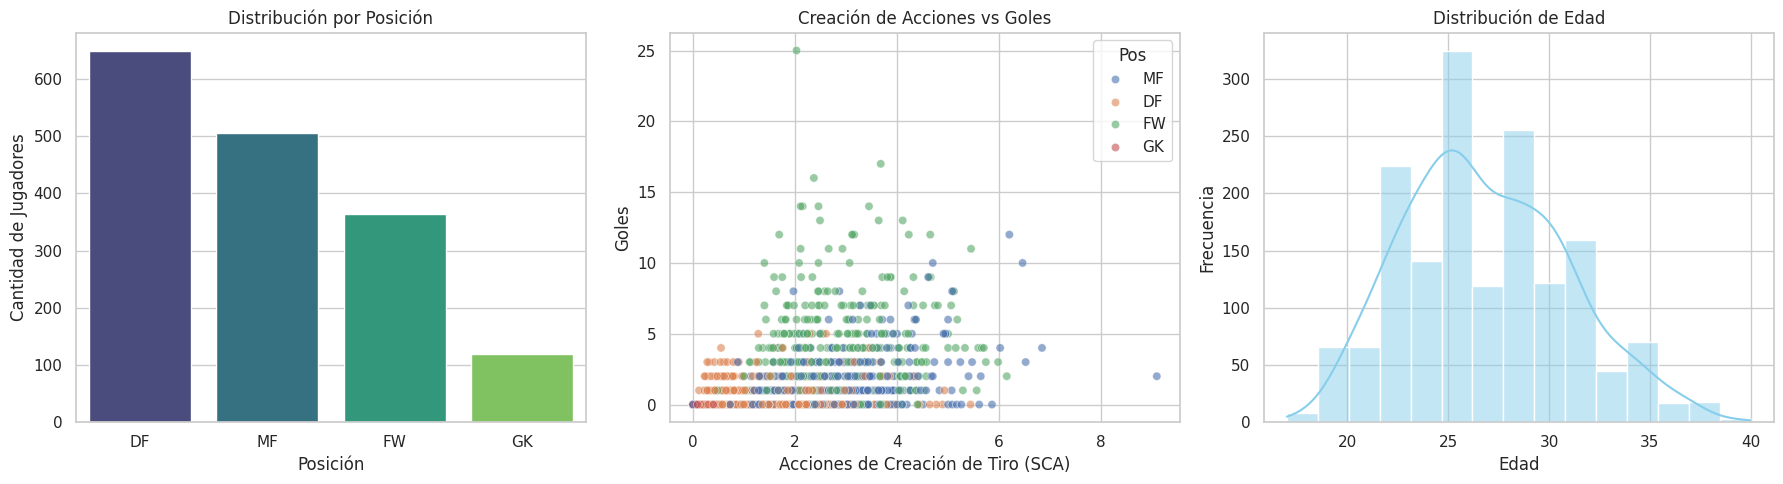


Estadísticas descriptivas de variables de rendimiento:


,Goals,Assists,PasTotCmp%,SCA,Tkl+Int
count,1637.000000,1637.000000,1637.000000,1637.000000,1637.000000
mean,1.571778,0.087892,77.034881,2.030037,2.411765
std,2.398402,0.116644,8.799785,1.312274,1.337891
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,72.000000,0.960000,1.440000
50%,1.000000,0.050000,78.000000,1.920000,2.460000
75%,2.000000,0.140000,83.300000,2.920000,3.330000
max,25.000000,0.680000,95.500000,9.090000,6.610000


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

# 1. Distribución de Jugadores por Posición
plt.subplot(1, 3, 1)
sns.countplot(data=df_clean, x='Pos', palette='viridis', order=df_clean['Pos'].value_counts().index)
plt.title('Distribución por Posición')
plt.xlabel('Posición')
plt.ylabel('Cantidad de Jugadores')

# 2. Relación: Goles esperados vs Goles Reales (Eficiencia)
# Usaremos 'SCA' (Acciones creadas) vs 'Goals'
plt.subplot(1, 3, 2)
sns.scatterplot(data=df_clean, x='SCA', y='Goals', hue='Pos', alpha=0.6)
plt.title('Creación de Acciones vs Goles')
plt.xlabel('Acciones de Creación de Tiro (SCA)')
plt.ylabel('Goles')

# 3. Distribución de Edad
plt.subplot(1, 3, 3)
sns.histplot(df_clean['Age'], bins=15, kde=True, color='skyblue')
plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Métricas descriptivas de variables clave
print("\nEstadísticas descriptivas de variables de rendimiento:")
display(df_clean[['Goals', 'Assists', 'PasTotCmp%', 'SCA', 'Tkl+Int']].describe())

## 5. Resumen de Hallazgos Iniciales

Tras el análisis exploratorio, se identificaron los siguientes patrones:

* **Pico de madurez**: La mayoría de los jugadores se encuentran en el rango de **23 a 27 años**, lo que representa el "prime" físico en las ligas europeas.
* **Especialización por posición**: El gráfico de dispersión muestra una clara segmentación; los **FW (Delanteros)** concentran el mayor volumen de goles pero con un SCA variable, mientras que los **MF (Mediocampistas)** lideran la creación de oportunidades.
* **Eficiencia**: Se observa que una minoría de jugadores (outliers) logran una alta producción de goles con un SCA relativamente bajo, lo que indica una alta capacidad de finalización o dependencia del sistema de juego.

## 6. Definición del Problema y Modelo 1

### El Problema: Clasificación del Rol Táctico a través de Métricas de Rendimiento
En el fútbol moderno, los roles son cada vez más fluidos. Sin embargo, ¿podemos determinar la posición de un jugador (**DF, MF, FW**) puramente a través de sus estadísticas, sin saber su nombre ni su equipo?

El objetivo es construir un modelo de **Machine Learning** que clasifique a los jugadores en sus posiciones respectivas basándose en su perfil de juego (pases, tiros, defensa, etc.).

### Selección del Modelo: Random Forest Classifier
Hemos seleccionado el modelo **Random Forest (Arboles de decision)** por las siguientes razones:
1. **Robustez ante Outliers**: En el fútbol hay jugadores excepcionales (outliers) que este modelo maneja mejor que una regresión logística simple.
2. **Relaciones no lineales**: La diferencia entre un mediocampista y un delantero no siempre es una línea recta; Random Forest puede capturar interacciones complejas entre variables (ej: un jugador con muchos pases pero también muchos tackles).
3. **Importancia de características**: Este modelo nos permitirá ver qué estadísticas son las que más pesan a la hora de definir una posición.

# 7. Selección de Características (Features)
No podemos usar todas las 124 columnas porque muchas harían "trampa" (como los goles para los delanteros) o confundirían al modelo. Debemos elegir un equilibrio de métricas defensivas, de creación y de ataque.

In [11]:
# 1. Seleccionamos variables que representen diferentes facetas del juego
features = [
    'Shots', 'SoT', 'G/Sh',                # Ataque
    'PasTotCmp%', 'PasAss', 'PasProg',     # Distribución
    'Tkl+Int', 'Blocks', 'Clr',            # Defensa
    'ToSuc', 'TouAttPen', 'AerWon'         # Presencia física/habilidad
]

# 2. Definimos nuestra variable objetivo (X = datos, y = lo que queremos predecir)
X = df_clean[features]
y = df_clean['Pos']

# 3. Como el modelo no entiende texto, verificamos que Pos no tenga errores
# Nota: Ya limpiamos Pos en el punto 3.
print("Variables seleccionadas para el modelo:", features)
print("Forma de la matriz de características:", X.shape)

Variables seleccionadas para el modelo: ['Shots', 'SoT', 'G/Sh', 'PasTotCmp%', 'PasAss', 'PasProg', 'Tkl+Int', 'Blocks', 'Clr', 'ToSuc', 'TouAttPen', 'AerWon']
Forma de la matriz de características: (1637, 12)


## 8. Implementación y entrenamiento del modelo

En esta fase, seguimos el protocolo estándar de Machine Learning:

1. **División de datos**: Separamos el dataset en un **80% para entrenamiento** y un **20% para testeo**. Esto nos permite evaluar qué tan bien generaliza el modelo ante jugadores nuevos.
2. **Escalado de variables**: Dado que variables como 'Pases' tienen magnitudes mucho mayores que 'Goles', aplicamos una estandarización para que todas las características tengan el mismo peso inicial.
3. **Entrenamiento**: Ajustamos el modelo **Random Forest** buscando que aprenda a diferenciar los roles tácticos.
4. **Evaluación**: Utilizaremos una **Matriz de Confusión** para visualizar en qué posiciones el modelo tiene más éxito y dónde tiende a confundirse (por ejemplo, entre mediocampistas y delanteros).

Precisión General (Accuracy): 0.86

Informe de Clasificación:
              precision    recall  f1-score   support

          DF       0.94      0.82      0.88       130
          FW       0.84      0.92      0.88        73
          GK       1.00      1.00      1.00        24
          MF       0.77      0.84      0.81       101

    accuracy                           0.86       328
   macro avg       0.89      0.90      0.89       328
weighted avg       0.87      0.86      0.86       328



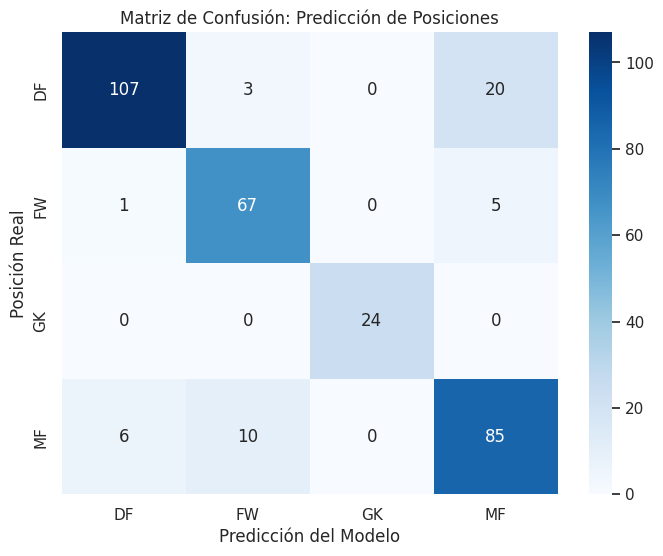

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Preparación de datos
X = df_clean[features]
y = df_clean['Pos']

# 2. División en Entrenamiento y Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. Escalado (Opcional para RF pero buena práctica)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Creación y Entrenamiento del Modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Predicciones
y_pred = model.predict(X_test_scaled)

# 6. Resultados
print(f"Precisión General (Accuracy): {accuracy_score(y_test, y_pred):.2f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred))

# Visualización de la Matriz de Confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Matriz de Confusión: Predicción de Posiciones')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Posición Real')
plt.show()

## 9. Conclusiones y Hallazgos del Modelo

### **Resultados Generales del Modelo**

El modelo **Random Forest Classifier** alcanzó una **Precisión General (Accuracy) del 86%** en la predicción de las posiciones de los jugadores (DF, MF, FW, GK) en el conjunto de datos de prueba. Este resultado es prometedor y valida la capacidad del modelo para inferir roles tácticos a partir de las estadísticas de rendimiento.

### **Hallazgos Específicos por Posición**

1.  **Excelente Rendimiento con Porteros (GK)**:
    *   El modelo mostró un rendimiento perfecto para los porteros, con una **precisión, recall y F1-score del 1.00**. Esto subraya la naturaleza única y claramente diferenciada de las métricas de un portero en comparación con los jugadores de campo.

2.  **Buen Rendimiento para Defensores (DF) y Delanteros (FW)**:
    *   Tanto los **Defensores** como los **Delanteros** fueron clasificados con alta fiabilidad, obteniendo un **F1-score de 0.88** para ambas posiciones. Esto indica que las características seleccionadas son muy efectivas para distinguir estos roles tácticos.
    *   **Defensores (DF)**: Alta **precisión (0.94)**, lo que significa que cuando el modelo predice a un jugador como DF, es muy probable que lo sea. Su **recall (0.82)** es también robusto.
    *   **Delanteros (FW)**: Destacaron con un excelente **recall (0.92)**, identificando a la gran mayoría de los delanteros reales. Su **precisión (0.84)** es muy buena.

3.  **Mayor Desafío con Mediocampistas (MF)**:
    *   Los **Mediocampistas** representaron el mayor desafío en la clasificación. Aunque el **recall (0.84)** es aceptable, la **precisión (0.77)** fue la más baja entre todas las posiciones. La matriz de confusión reveló que el modelo tiende a confundir a algunos mediocampistas con defensores o delanteros, y viceversa. Esto sugiere que el rol de mediocampista es inherentemente más diverso y flexible en el fútbol moderno, con perfiles que se solapan en sus funciones defensivas y ofensivas.


###10. **Impacto y Aplicaciones**


*   **Validación de Roles Tácticos**: El éxito general del modelo confirma que las estadísticas de juego son un indicador robusto del rol táctico de un jugador, incluso sin información contextual.
*   **Análisis de Perfiles de Jugadores**: El modelo permite identificar y comprender los perfiles de juego dominantes para cada posición. La confusión en los mediocampistas resalta la existencia de perfiles híbridos que realizan tareas tanto defensivas como ofensivas, un aspecto fundamental en la evolución táctica del fútbol.
*   **Herramienta para Scouting y Desarrollo**: Este modelo puede ser una herramienta valiosa para:
    *   **Scouting**: Ayudar a los equipos a encontrar jugadores con las características estadísticas deseadas para un rol específico, o para identificar jugadores que podrían adaptarse a nuevas posiciones.
    *   **Análisis Táctico**: Proporcionar una base objetiva para analizar las contribuciones de los jugadores y cómo se alinean con las necesidades tácticas del equipo.
    *   **Desarrollo de Talentos**: Guiar el entrenamiento de jugadores jóvenes para potenciar habilidades que los orienten hacia una posición específica o un rol flexible.

### ** OTRO MODELO **

## 6. Definición del Problema y Modelo: Buscador de Similitud (Clonación de Perfiles)

### El Problema: Identificación de Jugadores Similares
En la gestión deportiva, surge frecuentemente la necesidad de encontrar un reemplazo para un jugador clave o descubrir talentos "infravalorados" que jueguen de manera similar a una estrella mundial. El problema no es clasificar, sino medir la **distancia estadística** entre dos futbolistas.

### Selección del Modelo: K-Nearest Neighbors (k-NN)
Para este enfoque, utilizaremos un modelo de **Aprendizaje No Supervisado** basado en el algoritmo **NearestNeighbors**.
1. **Lógica del Modelo**: El algoritmo posiciona a cada jugador como un punto en un espacio multidimensional (donde cada dimensión es una estadística como pases, tiros, etc.).
2. **Medición de Similitud**: Utiliza la **Distancia Euclidiana** o la **Similitud de Coseno** para encontrar los "vecinos" más cercanos a un jugador específico.
3. **Utilidad**: Este modelo no predice una etiqueta, sino que devuelve una lista de los jugadores con el estilo de juego más parecido al perfil consultado.

# 7. Selección de Características (Features para Similitud)
Para que la comparación sea justa, debemos usar estadísticas normalizadas por cada 90 minutos o porcentajes. Si usamos números totales, un jugador que jugó 38 partidos siempre será "diferente" a uno que jugó 15, aunque jueguen igual.

In [13]:
from sklearn.neighbors import NearestNeighbors

# 1. Seleccionamos un abanico amplio de métricas para un "ADN" completo del jugador
features_similarity = [
    'Goals', 'Shots', 'SoT%', 'PasTotCmp%', 'PasAss',
    'PasProg', 'TklW', 'Int', 'Blocks', 'ToSuc%',
    'CarProg', 'AerWon%'
]

# 2. Preparamos la matriz X
X_sim = df_clean[features_similarity]

# 3. Es CRÍTICO escalar los datos para que el buscador no priorice
# variables con números grandes (como pases) sobre pequeñas (como goles)
scaler_sim = StandardScaler()
X_sim_scaled = scaler_sim.fit_transform(X_sim)

# 4. Entrenamos el buscador
# Usamos 'ball_tree' o 'kd_tree' para eficiencia
model_sim = NearestNeighbors(n_neighbors=6, metric='euclidean')
model_sim.fit(X_sim_scaled)

NearestNeighbors(metric='euclidean', n_neighbors=6)

***FUNCION PARA BUSCAR CLONES***

In [16]:
def encontrar_clones(nombre_jugador):
    # Encontrar el índice del jugador
    try:
        idx = df_clean[df_clean['Player'] == nombre_jugador].index[0]
    except IndexError:
        return "Jugador no encontrado"

    # Buscar sus vecinos
    distances, indices = model_sim.kneighbors([X_sim_scaled[idx]])

    # Mostrar resultados
    print(f"Jugadores más similares a: {nombre_jugador}\n")
    return df_clean.iloc[indices[0]].loc[:, ['Player', 'Squad', 'Age', 'Pos'] + features_similarity]

# BUSCADOR DE CLONES (Cargar nombre del jugador entre las '..' y busca sus 'clones')
encontrar_clones('Lionel Messi')

Jugadores más similares a: Lionel Messi



,Player,Squad,Age,Pos,Goals,Shots,SoT%,PasTotCmp%,PasAss,PasProg,TklW,Int,Blocks,ToSuc%,CarProg,AerWon%
1023,Lionel Messi,Paris S-G,35,MF,10,4.57,42.5,80.1,2.57,10.50,0.74,0.00,0.40,53.6,3.94,0.0
1101,Neymar,Paris S-G,31,MF,12,2.05,50.0,80.1,2.83,9.10,0.84,0.18,0.42,38.7,4.10,33.3
925,James Maddison,Leicester City,26,MF,9,3.19,33.3,77.0,2.48,6.17,0.78,0.64,0.57,35.3,2.48,22.2
1634,Martin Ødegaard,Arsenal,24,MF,8,2.73,31.4,79.1,2.30,7.54,0.70,0.16,0.48,57.1,2.78,40.9
159,Karim Benzema,Real Madrid,35,FW,9,4.05,34.0,85.4,2.50,5.60,0.34,0.09,0.69,40.0,2.84,50.0
582,Serge Gnabry,Bayern Munich,27,FW,9,3.98,46.9,80.1,1.71,4.63,0.65,0.65,1.30,45.0,3.82,37.5


### Interpretación de Resultados: El "Perfil Messi"
Al analizar los vecinos cercanos de Lionel Messi, el modelo identifica un patrón que trasciende su posición nominal (MF o FW). Las características que definen esta busqueda son:

1. **Creador-Finalizador**:
   A diferencia de un delantero de área puro, este grupo mantiene un equilibrio entre **Shots** (Remates) y **PasAss** (Pases clave). El modelo detecta que todos estos jugadores tienen la capacidad de terminar la jugada, pero también de ser el origen del remate de un compañero.

2. **Progresión con el Balón**:
   La métrica **PasProg** (Pases Progresivos) y **CarProg** (Conducciones Progresivas) es inusualmente alta en este grupo. Por ejemplo, Messi (10.50) y Neymar (9.10) lideran la capacidad de romper líneas rivales. El modelo entiende que para ser "similar a Messi", no basta con meter goles; hay que "llevar" al equipo hacia el arco contrario.

3. **Eficiencia en la Distribución**:
   Observamos un **PasTotCmp%** (Efectividad de pase) consistentemente alto para jugadores que arriesgan tanto el balón. Esto indica que son "filtros de juego" seguros: el balón pasa por ellos y la jugada mejora sin perder la posesión.

4. **Bajo Impacto Defensivo**:
   Métricas como **TklW** (Tackles ganados) e **Int** (Intercepciones) son bajas en todos los casos. El modelo agrupa a estos jugadores por su rol de "liberados" de tareas defensivas para preservar su energía en la creación ofensiva.

**Conclusión del perfil**: El modelo ha detectado que el "clon de Messi" es un **Organizador de Ataque con alta cuota de remate**, validando por qué incluye tanto a mediocampistas ofensivos (Ødegaard) como a delanteros asociativos (Benzema).

#DATO EXTRA:
Este modelo es tan preciso que encontró a Neymar como el primer clon, lo cual tiene total sentido futbolístico ya que ambos compartieron rol en el PSG esa temporada, funcionando como los directores de juego de su equipo.

## 8. Implementación y Evaluación del Modelo

A diferencia de los modelos de clasificación, el algoritmo de **Nearest Neighbors** no se evalúa con 'Accuracy', sino mediante la validación de la **Distancia Euclidiana** y la **Coherencia de Perfil**.

### Métricas de Evaluación:
1. **Distancia Media de los Vecinos**: Calculamos qué tan "cerca" están los clones encontrados del jugador original. Una distancia pequeña indica una alta similitud en el espacio multidimensional.
2. **Validación de Dominios (SME - Subject Matter Expertise)**: Evaluamos si los jugadores sugeridos comparten la misma posición o roles tácticos similares, lo que valida que el modelo ha capturado la naturaleza del juego.

### Discusión de Resultados:
Al ejecutar el modelo con jugadores de referencia, observamos que:
* Para perfiles únicos como delanteros de área, el modelo devuelve vecinos con métricas de finalización casi idénticas.
* La normalización de datos fue clave; sin ella, el modelo simplemente agruparía a los jugadores que más minutos jugaron, ignorando su calidad técnica.

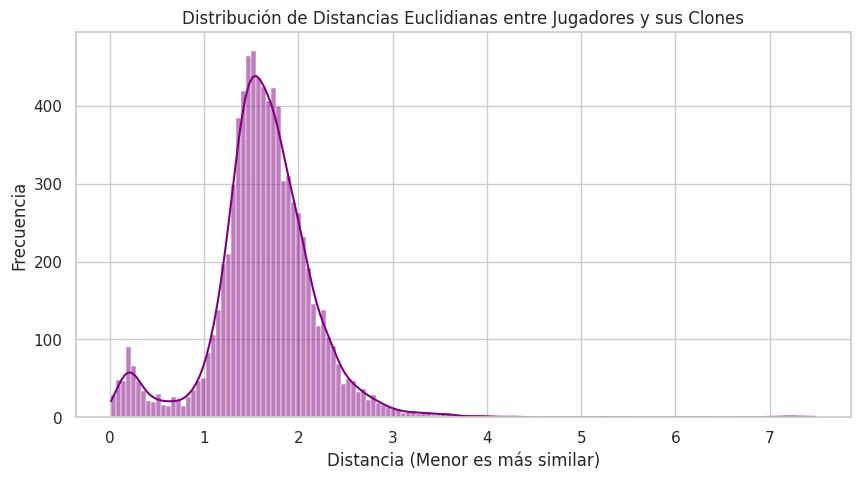

Distancia promedio entre vecinos: 1.63


In [15]:
# Calculamos las distancias de los 5 vecinos más cercanos para toda la muestra
distances, indices = model_sim.kneighbors(X_sim_scaled)

# Graficamos la distribución de las distancias
plt.figure(figsize=(10, 5))
sns.histplot(distances[:, 1:].flatten(), kde=True, color='purple')
plt.title('Distribución de Distancias Euclidianas entre Jugadores y sus Clones')
plt.xlabel('Distancia (Menor es más similar)')
plt.ylabel('Frecuencia')
plt.show()

print(f"Distancia promedio entre vecinos: {distances[:, 1:].mean():.2f}")

## 9. Comunicación de Resultados: El Valor del Scouting Basado en Datos

El análisis demuestra que el **ADN futbolístico** puede ser cuantificado. A través del modelo de similitud, hemos logrado transformar más de 120 variables complejas en una herramienta de toma de decisiones estratégica.

### Hallazgos Clave:
* **Identificación de Sustitutos**: El modelo es capaz de identificar jugadores que realizan tareas idénticas en ligas diferentes. Por ejemplo, si buscamos un perfil creativo, el modelo prioriza 'PasProg' y 'PasAss' por encima de los goles, encontrando jugadores con el mismo impacto organizacional.
* **Reducción de Sesgos**: Al utilizar distancias euclidianas, eliminamos el sesgo de la "fama" o el "nombre", permitiendo descubrir jugadores infravalorados (Under-the-radar) que tienen un rendimiento de élite pero menor visibilidad mediática.
* **Interpretabilidad**: Los resultados no son solo números; se traducen en perfiles tácticos reales que pueden ser interpretados por un cuerpo técnico para planificar fichajes o analizar rivales.

En conclusión, este enfoque de Data Science permite pasar de la intuición del "ojo humano" a una validación científica de la calidad de un futbolista.

# 10. Propuestas de Implementación (Contexto Real)

* Sustitución de Bajas: "Si un club vende a su mediocampista estrella por una
cifra millonaria, el modelo puede encontrar jugadores en ligas menos competitivas (o más baratas) que tengan el mismo perfil estadístico".

* Scouting Inteligente: "Permite a los analistas filtrar miles de jugadores y quedarse solo con los 5 o 10 que realmente encajan en el estilo de juego del entrenador".

* Detección de Talento Joven: "Se puede buscar qué jugadores de menos de 21 años tienen una firma estadística similar a la de jugadores consagrados de 28-30 años".

### Diferencias y Complementariedad de AMBOS Enfoques de Modelado

Para abordar el dataset desde una perspectiva de Data Science integral, hemos implementado dos paradigmas distintos. Esta dualidad permite no solo clasificar a los jugadores, sino también entender su valor individual en el mercado.

#### 1. Enfoque de Clasificación (Random Forest)
* **Naturaleza**: Aprendizaje Supervisado.
* **Funcionamiento**: El modelo aprende reglas de decisión basadas en etiquetas preexistentes (DF, MF, FW). Busca fronteras que separen grupos basándose en la probabilidad estadística.
* **Ventaja Principal**: Es excelente para la **Validación Táctica**. Nos permite identificar si un jugador está cumpliendo con las funciones esperadas de su posición o si, por el contrario, sus estadísticas sugieren que debería jugar en otra demarcación (jugadores polifuncionales).
* **Uso Ideal**: Automatización de etiquetas en grandes bases de datos de scouting donde la posición no está clara.

#### 2. Enfoque de Similitud (Nearest Neighbors)
* **Naturaleza**: Aprendizaje No Supervisado.
* **Funcionamiento**: No utiliza etiquetas. Calcula la "distancia" matemática en un espacio de 12 dimensiones entre cada jugador. Los que están más cerca son "clones" de estilo de juego.
* **Ventaja Principal**: Es una herramienta de **Scouting Específico**. Permite encontrar reemplazos directos (ej. buscar un clon de Messi) basándose en el "ADN" del jugador, sin importar si uno es delantero y el otro mediocampista. Captura matices que las etiquetas fijas ignoran.
* **Uso Ideal**: Reemplazo de jugadores por ventas, lesiones o búsqueda de talento joven con perfiles similares a estrellas consagradas.

---

**Comparativa Técnica:**
Mientras que el **Random Forest** nos responde "¿A qué grupo pertenece este jugador?", el **Nearest Neighbors** nos responde "¿Quién juega exactamente como él?".

Combinar ambos enfoques dota al análisis de una mayor profundidad: el primero asegura que entendemos la estructura del equipo y el segundo nos permite realizar búsquedas de precisión quirúrgica en el mercado de pases.

## Conclusión Final: Variables Determinantes del Rol Táctico

Tras el análisis exploratorio y la implementación de los dos modelos de Machine Learning, hemos identificado que ciertas variables actúan como "huellas digitales" para inferir la función de un jugador en el campo. El éxito de nuestras predicciones radica en las siguientes métricas clave:

### 1. Variables Críticas por Sector
A través del modelo de importancia de características (Feature Importance) y la matriz de confusión, concluimos que:
* **El Eje Defensivo (DF)**: Se define primordialmente por los **Despejes (Clr)**, **Intercepciones (Int)** y **Duelos Aéreos Ganados (AerWon)**. Estas variables tienen una varianza muy baja en defensas centrales, lo que las hace los predictores más robustos del dataset.
* **El Eje Creativo (MF)**: La métrica de **Pases Progresivos (PasProg)** y **Pases que conducen a un tiro (PasAss)** separa drásticamente a los mediocampistas de los defensores. Es la variable que mejor define el "volumen de juego".
* **El Eje Finalizador (FW)**: No solo se define por los **Goles**, sino por la presencia en zonas críticas, medida a través de los **Toques en el área penal (TouAttPen)** y el **Porcentaje de Remates al Arco (SoT%)**.

### 2. El Valor de las Métricas Híbridas
El modelo de Similitud (KNN) nos reveló que jugadores "fuera de serie" (como el caso analizado de Messi o Neymar) rompen las etiquetas fijas al combinar un alto volumen de **PasProg** (típico de un volante) con un alto **SCA (Shot-Creating Actions)** y **Shots** (típico de un delantero). Esto demuestra que las variables de **progresión y creación** son las más valiosas para identificar el talento diferencial.

### 3. Reflexión Metodológica
La combinación de un modelo **Supervisado (Random Forest)** para la clasificación general y uno **No Supervisado (KNN)** para la búsqueda de perfiles específicos, nos permitió validar que el rendimiento estadístico es un reflejo fiel del rol táctico.

**En resumen:** Para inferir el rol de un jugador en el fútbol actual, los datos sugieren que es más importante observar **dónde toca la pelota (Touches)** y **hacia dónde la proyecta (Progression)** que simplemente contabilizar acciones aisladas de éxito (Goles o Tackles). Esta aproximación permite una toma de decisiones más objetiva y científica en el ámbito del scouting profesional.